In [1]:
from types import new_class

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
confusion_matrix,
accuracy_score,
recall_score,
f1_score,
roc_curve,
auc,
)

plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
#Create a small synthetic dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy':   [0,        1,       0,        1,        0,        1,        0,       1],
    'Play':    [1,        0,       1,        1,        0,        0,        1,       0]
}

df_synthetic = pd.DataFrame(data)
df_synthetic

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


In [3]:
df_synthetic['Weather_num'] = df_synthetic['Weather'].map({'sunny':1, 'rainy':0})
x_syn = df_synthetic[['Weather_num', 'Windy']]
y_syn = df_synthetic['Play']
print(x_syn)
print(y_syn)

   Weather_num  Windy
0          NaN      0
1          NaN      1
2          NaN      0
3          NaN      1
4          NaN      0
5          NaN      1
6          NaN      0
7          NaN      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: Play, dtype: int64


In [4]:
tree_syn= DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(x_syn, y_syn)
tree_syn.fit(x_syn, y_syn)
tree_syn

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


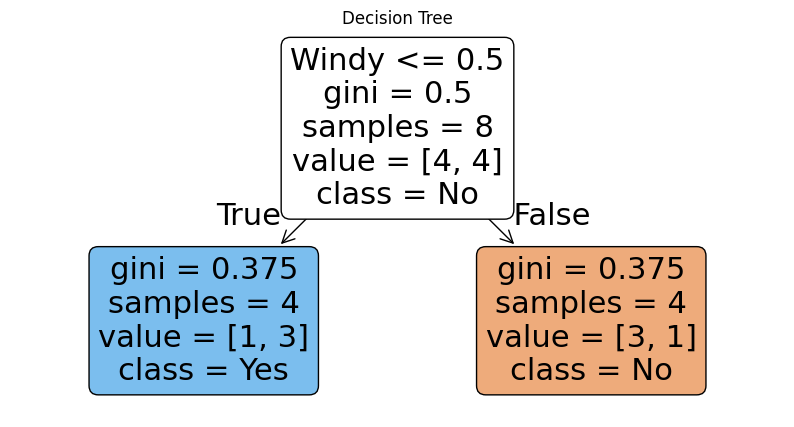

In [5]:
plt.figure(figsize=(10, 5))
plot_tree(tree_syn,
          feature_names=['Weather_num', 'Windy'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,)
plt.title('Decision Tree')
plt.show()

#### 11.5 Overfitting and Pruning of Decision Tree


In [6]:
# Example: Sunny (1), not windy (0)
example_1 = pd.DataFrame([[1,0]], columns = ['Weather_num', 'Windy'])
pred_1 = tree_syn.predict(example_1)[0]
print('Sunny, not windy -> Play prediction: ',pred_1)

print()
# Example: Rainy (0), windy (1)
example_2 = pd.DataFrame([[0,1]], columns = ['Weather_num', 'Windy'])
pred_2 = tree_syn.predict(example_2)[0]
print('Rainy, windy -> Play prediction: ',pred_2)

Sunny, not windy -> Play prediction:  1

Rainy, windy -> Play prediction:  0


In [7]:
#Create a slightly larger synthetic dataset
from sklearn.datasets import make_classification
x_big, y_big = make_classification(
    n_samples = 400,
    n_features = 5,
    n_informative=3,
    n_redundant=0,
    n_classes = 2,
    random_state = 42,
)

X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    x_big, y_big, test_size=0.3, random_state=42
)

X_train_big.shape, X_test_big.shape

((280, 5), (120, 5))

In [8]:
#Train a deep tree vs a pruned tree
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_big, y_train_big)

pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_pruned = pruned_tree.predict(X_train_big)
y_test_pred_pruned = pruned_tree.predict(X_test_big)

print('Deep tree – train accuracy:', round(accuracy_score(y_train_big, y_train_pred_deep), 3))
print('Deep tree – test accuracy :', round(accuracy_score(y_test_big, y_test_pred_deep), 3))
print()
print('Pruned tree – train accuracy:', round(accuracy_score(y_train_big, y_train_pred_pruned), 3))
print('Pruned tree – test accuracy :', round(accuracy_score(y_test_big, y_test_pred_pruned), 3))

Deep tree – train accuracy: 1.0
Deep tree – test accuracy : 0.883

Pruned tree – train accuracy: 0.904
Pruned tree – test accuracy : 0.892


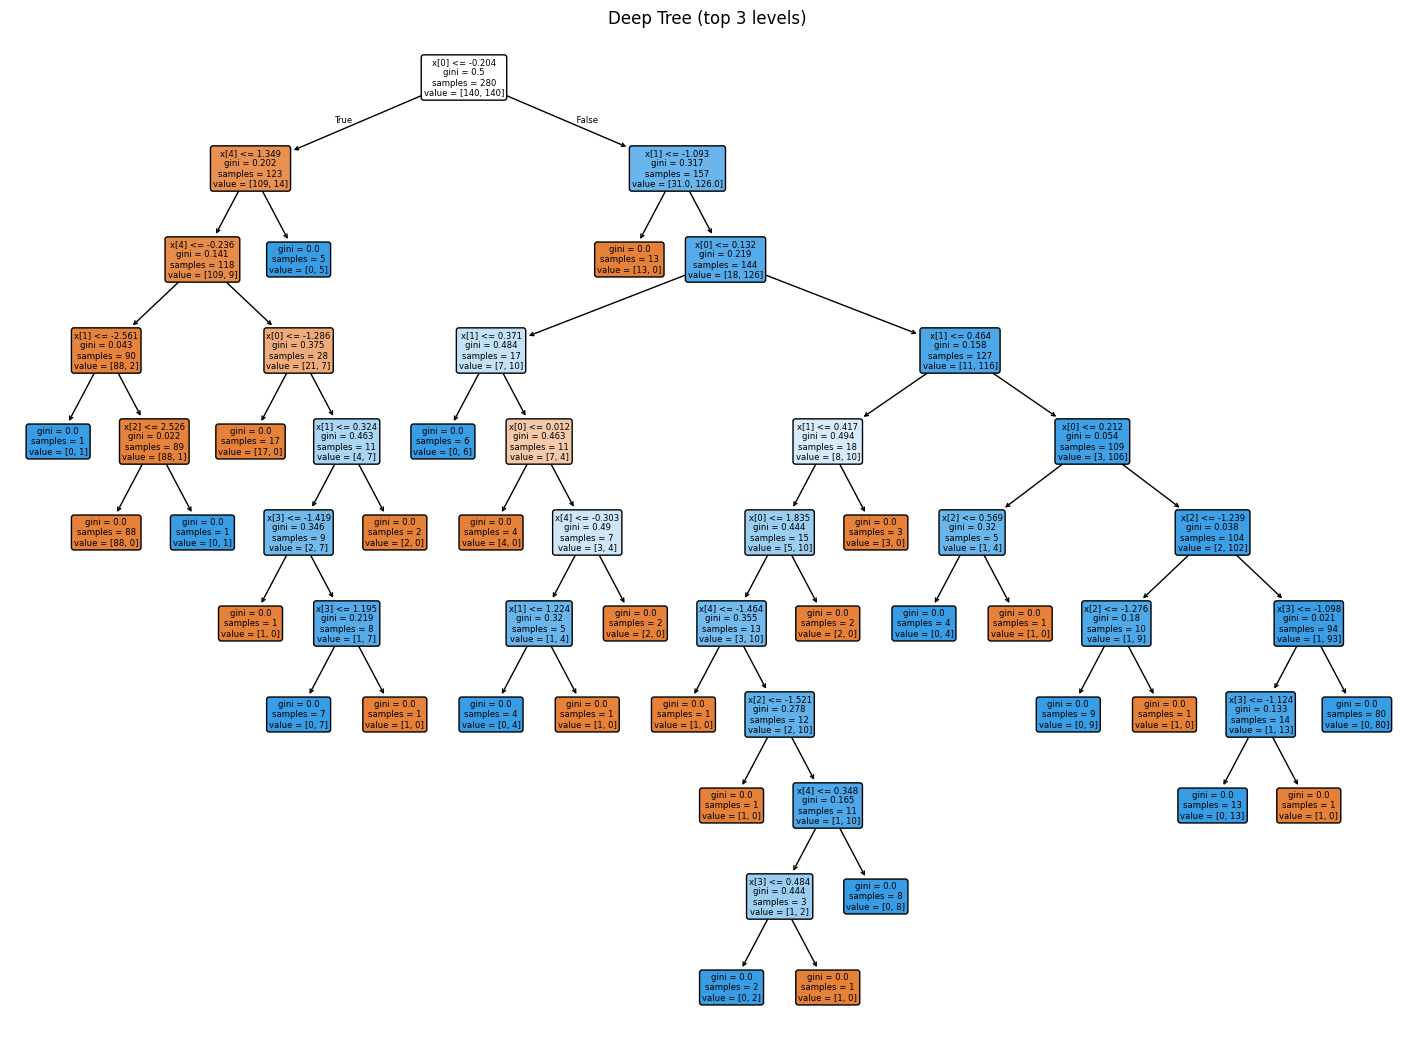

In [9]:
# Plot deep tree (showing only top levels for readability)
plt.figure(figsize=(18,13))
plot_tree(deep_tree, filled=True,rounded=True)
plt.title("Deep Tree (top 3 levels)")
plt.show()

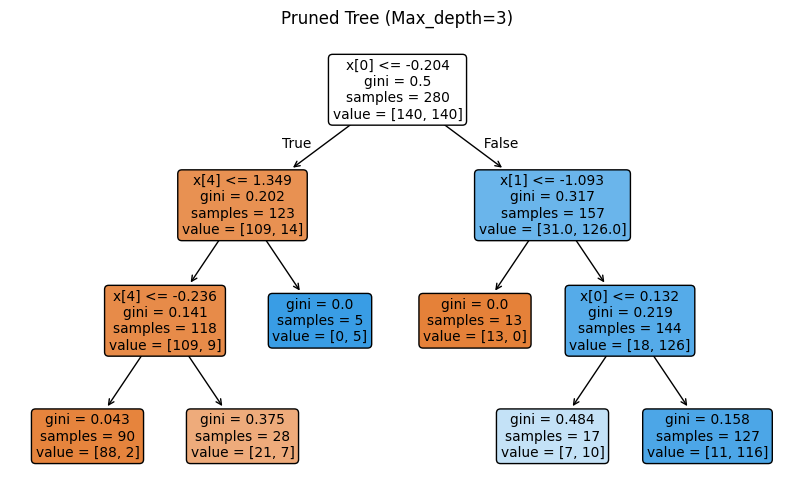

In [10]:
# Plot pruned tree
plt.figure(figsize=(10,6))
plot_tree(pruned_tree, filled=True,rounded=True)
plt.title("Pruned Tree (Max_depth=3)")
plt.show()

## 11.6 Evaluating a Decision Tree (Accuracy, Precision, Recall, F1, Confusion Matrix)_Part 01

In [11]:
np.random.seed(42)
n_samples = 300

age = np.random.randint(30, 80, size=n_samples)
chol = np.random.randint(150, 300, size=n_samples)
thalach = np.random.randint(90, 200, size=n_samples)

# We create a simple rule-based probability for disease just for realism
risk_score = 0.03 * (age - 40) + 0.02 * (chol - 200) - 0.02 * (thalach - 140)
prob = 1 / (1 + np.exp(-0.05 * risk_score))

target = (prob > np.median(prob)).astype(int)

df_heart = pd.DataFrame({
    'age': age,
    'chol': chol,
    'thalach': thalach,
    'target': target
})

df_heart.head(10)

,age,chol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0
5,50,295,151,1
6,68,277,152,1
7,48,259,114,1
8,52,231,145,0
9,40,203,122,0


In [12]:
#Train-test split and model training
X_heart = df_heart[['age','chol','thalach']]
y_heart = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

tree_heart = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_heart.fit(X_train_h, y_train_h)

tree_heart

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
#Confusion matrix
y_pred_h = tree_heart.predict(X_test_h)

cm = confusion_matrix(y_test_h, y_pred_h)
print(cm)

[[23  3]
 [ 6 28]]


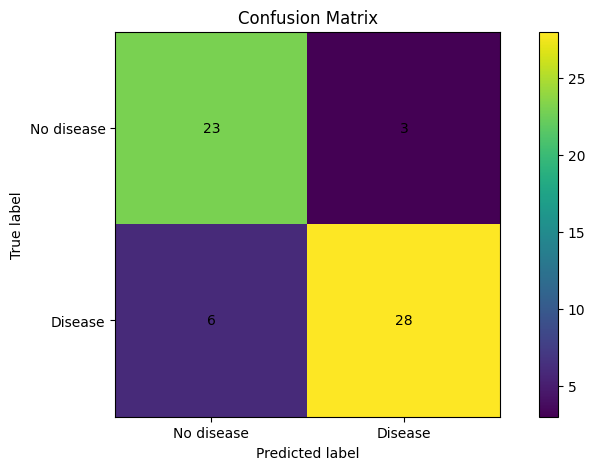

In [14]:
#Plot of Confusion Matrix
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation = 'nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Show all ticks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["No disease", 'Disease'])
ax.set_yticklabels(["No disease", 'Disease'])

# Loop over data dimensions and create text annotations.
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j,i,cm[i,j], ha='center', va='center')

plt.colorbar(im)
plt.show()

In [16]:
from sklearn.metrics import precision_score

#Accuracy, precision, recall, F1
acc = accuracy_score(y_test_h,y_pred_h)
prec = precision_score(y_test_h,y_pred_h)
rec = recall_score(y_test_h,y_pred_h)
f1 = f1_score(y_test_h,y_pred_h)

print('Accuracy :', round(acc, 3))
print('Precision:', round(prec, 3))
print('Recall   :', round(rec, 3))
print('F1 score :', round(f1, 3))

Accuracy : 0.85
Precision: 0.903
Recall   : 0.824
F1 score : 0.862


## 11.7 Evaluating a Decision Tree (Accuracy, Precision, Recall, F1, Confusion Matrix)_Part 02


In [17]:
#Accuracy, precision, recall, F1
acc = accuracy_score(y_test_h,y_pred_h)
prec = precision_score(y_test_h,y_pred_h)
rec = recall_score(y_test_h,y_pred_h)
f1 = f1_score(y_test_h,y_pred_h)

print('Accuracy :', round(acc, 3))
print('Precision:', round(prec, 3))
print('Recall   :', round(rec, 3))
print('F1 score :', round(f1, 3))

Accuracy : 0.85
Precision: 0.903
Recall   : 0.824
F1 score : 0.862


### 11.9 ROC Curve, AUC, and Threshold Interpretation_Part 01 and 02

In [19]:
#Predicted probabilities
y_proba_h = tree_heart.predict_proba(X_test_h)[:, 1]
y_proba_h[:10]

array([0.875     , 0.        , 0.04761905, 0.        , 0.875     ,
       1.        , 1.        , 1.        , 1.        , 0.        ])

In [20]:
#ROC curve and AUC
fpr,tpr,thresholds = roc_curve(y_test_h, y_proba_h)
roc_auc = auc(fpr,tpr)
print('AUC: ',round(roc_auc, 3))

AUC:  0.925


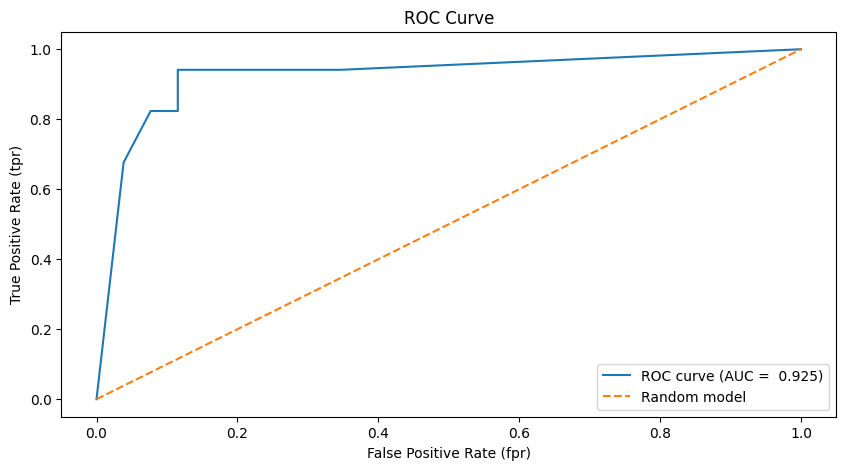

In [21]:
#Plot
plt.figure()
plt.plot(fpr,tpr, label=f'ROC curve (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random model')
plt.xlabel('False Positive Rate (fpr)')
plt.ylabel('True Positive Rate (tpr)')
plt.title("ROC Curve")
plt.legend()
plt.show()